# Multi-Algorithm Recommendation System Comparison

**Building a Recommendation System for E-Commerce**

This notebook implements three machine learning approaches — **Regression**, **Classification**, and **Clustering** — on e-commerce customer data, tunes each model with `GridSearchCV`, evaluates it with the appropriate metrics, and compares which approach best supports which business decision.

**Dataset:** `Ecommerce.csv` — customer-level behavioral data (RFM + engagement metrics).

**Note on target columns:** this dataset is customer-level (one row per customer) rather than interaction-level (one row per user-product pair), so it has no explicit `Rating` or `Purchase Status` column. The three tasks are mapped onto the closest real columns available:

| Task | Target used | Stands in for |
|---|---|---|
| Regression | `Monetary` (total customer value) | Rating |
| Classification | `Campaign_Response` (0/1) | Purchase Status |
| Clustering | Customer segments | Customer segments |


## Step 1: Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
%matplotlib inline


## Step 2: Load the Dataset

Check shape, columns, data types, missing values, and duplicates.

In [2]:
df = pd.read_csv("Ecommerce.csv")

print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())
print()
print(df.dtypes)


Shape: (10000, 14)

Columns: ['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns', 'Segment_Label']

Customer_ID                 str
Recency                   int64
Frequency                 int64
Monetary                  int64
Avg_Order_Value           int64
Session_Count             int64
Avg_Session_Duration    float64
Pages_Viewed              int64
Clicks                    int64
Campaign_Response         int64
Wishlist_Adds             int64
Cart_Abandon_Rate       float64
Returns                   int64
Segment_Label               str
dtype: object


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
df.head()


Missing values per column:
Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Clicks                  0
Campaign_Response       0
Wishlist_Adds           0
Cart_Abandon_Rate       0
Returns                 0
Segment_Label           0
dtype: int64

Duplicate rows: 0


,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold


## Step 3: Data Preprocessing

- No missing values and no duplicate rows were found, so no imputation or de-duplication is needed.
- `Customer_ID` is an identifier and is excluded from modeling.
- `Segment_Label` is a pre-existing categorical tier (Iron/Copper/Silver/Gold/Platinum). It is **not** used as an input feature — it's kept aside only to validate the clustering results later.
- All behavioral features are numeric, so no categorical encoding is required.
- Features are standardized with `StandardScaler` before Ridge Regression, Logistic Regression, and K-Means, since all three are scale-sensitive.


In [4]:
behavior_features = [
    "Recency", "Frequency", "Avg_Order_Value", "Session_Count",
    "Avg_Session_Duration", "Pages_Viewed", "Clicks",
    "Wishlist_Adds", "Cart_Abandon_Rate", "Returns"
]

df[behavior_features].describe()


,Recency,Frequency,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Wishlist_Adds,Cart_Abandon_Rate,Returns
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.665400,28.783000,146.599900,55.915800,15.444645,33.99840,1211.465100,28.618300,17.653052,7.268800
std,37.818734,23.133669,87.564246,43.551484,8.133285,21.14206,1058.875362,23.544257,10.013803,5.623247
min,1.000000,0.000000,10.000000,0.000000,1.000433,1.00000,50.000000,0.000000,0.007050,0.000000
25%,22.000000,10.000000,79.000000,22.000000,9.515457,18.00000,451.750000,11.000000,10.829601,3.000000
50%,40.000000,20.000000,135.000000,44.000000,14.305176,30.00000,871.000000,21.000000,15.908491,6.000000
75%,63.000000,40.000000,196.000000,75.000000,19.725305,46.00000,1518.000000,41.000000,22.769516,11.000000
max,179.000000,99.000000,399.000000,199.000000,39.995729,99.00000,4998.000000,99.000000,49.994254,24.000000


## Step 4: Regression Model — Predicting Customer Monetary Value

**Target:** `Monetary` (total amount spent by the customer)

Ridge Regression is used as the main model since the behavioral features are highly correlated with each other; Ridge's L2 penalty controls this multicollinearity better than plain Linear Regression.


In [5]:
X_reg = df[behavior_features]
y_reg = df["Monetary"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_scaler = StandardScaler()
Xr_train_s = reg_scaler.fit_transform(Xr_train)
Xr_test_s = reg_scaler.transform(Xr_test)


In [6]:
# Baseline: plain Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_s, yr_train)
lin_pred = lin_reg.predict(Xr_test_s)

lin_metrics = {
    "MAE": mean_absolute_error(yr_test, lin_pred),
    "RMSE": mean_squared_error(yr_test, lin_pred) ** 0.5,
    "R2": r2_score(yr_test, lin_pred),
}
lin_metrics


{'MAE': 587.5016246364168, 'RMSE': 861.3987098254884, 'R2': 0.8651792738047479}

In [7]:
# Ridge Regression - before tuning (default alpha = 1.0)
ridge_default = Ridge(alpha=1.0, random_state=42)
ridge_default.fit(Xr_train_s, yr_train)
ridge_default_pred = ridge_default.predict(Xr_test_s)

ridge_default_metrics = {
    "MAE": mean_absolute_error(yr_test, ridge_default_pred),
    "RMSE": mean_squared_error(yr_test, ridge_default_pred) ** 0.5,
    "R2": r2_score(yr_test, ridge_default_pred),
}
ridge_default_metrics


{'MAE': 587.4909546402797, 'RMSE': 861.3974488850188, 'R2': 0.8651796685134547}

In [8]:
# Ridge Regression - tuned with GridSearchCV
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(
    Ridge(random_state=42), ridge_param_grid,
    scoring="neg_mean_absolute_error", cv=5
)
ridge_grid.fit(Xr_train_s, yr_train)
best_ridge = ridge_grid.best_estimator_
ridge_tuned_pred = best_ridge.predict(Xr_test_s)

ridge_tuned_metrics = {
    "MAE": mean_absolute_error(yr_test, ridge_tuned_pred),
    "RMSE": mean_squared_error(yr_test, ridge_tuned_pred) ** 0.5,
    "R2": r2_score(yr_test, ridge_tuned_pred),
}
print("Best alpha:", ridge_grid.best_params_["alpha"])
ridge_tuned_metrics


Best alpha: 100


{'MAE': 586.7636789025005, 'RMSE': 861.4504790484306, 'R2': 0.8651630681292936}

In [9]:
pd.DataFrame({
    "Linear Regression": lin_metrics,
    "Ridge (default)": ridge_default_metrics,
    "Ridge (tuned)": ridge_tuned_metrics,
}).T


,MAE,RMSE,R2
Linear Regression,587.501625,861.398710,0.865179
Ridge (default),587.490955,861.397449,0.865180
Ridge (tuned),586.763679,861.450479,0.865163


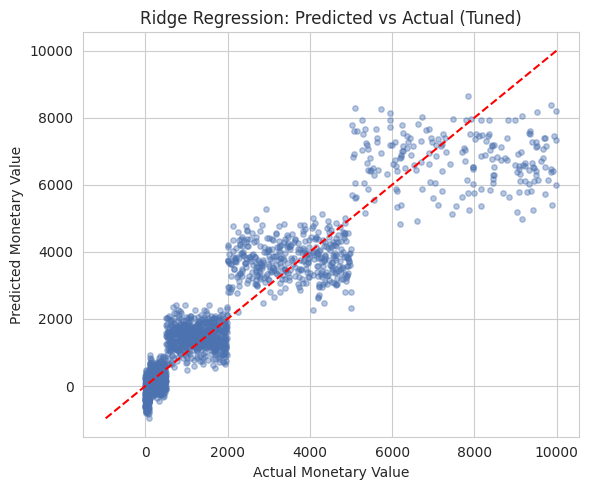

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(yr_test, ridge_tuned_pred, alpha=0.4, s=15, color="#4C72B0")
lims = [min(yr_test.min(), ridge_tuned_pred.min()), max(yr_test.max(), ridge_tuned_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1.5)
plt.xlabel("Actual Monetary Value")
plt.ylabel("Predicted Monetary Value")
plt.title("Ridge Regression: Predicted vs Actual (Tuned)")
plt.tight_layout()
plt.show()


**Business meaning:** an R² above 0.85 means the model explains most of the variation in customer spend using only behavioral signals. This lets the business estimate a customer's likely value before they've spent that much — useful for prioritizing retention offers or VIP treatment.

## Step 5: Classification Model — Predicting Campaign Response

**Target:** `Campaign_Response` (1 = customer responded to a marketing campaign, 0 = did not)

Logistic Regression is used to predict this binary outcome.


In [11]:
X_clf = df[behavior_features]
y_clf = df["Campaign_Response"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_scaler = StandardScaler()
Xc_train_s = clf_scaler.fit_transform(Xc_train)
Xc_test_s = clf_scaler.transform(Xc_test)


In [12]:
# Logistic Regression - before tuning (defaults)
logreg_default = LogisticRegression(max_iter=200, random_state=42)
logreg_default.fit(Xc_train_s, yc_train)
logreg_default_pred = logreg_default.predict(Xc_test_s)

logreg_default_metrics = {
    "Accuracy": accuracy_score(yc_test, logreg_default_pred),
    "Precision": precision_score(yc_test, logreg_default_pred),
    "Recall": recall_score(yc_test, logreg_default_pred),
    "F1": f1_score(yc_test, logreg_default_pred),
}
logreg_default_metrics


{'Accuracy': 0.6885,
 'Precision': 0.6767676767676768,
 'Recall': 0.48259303721488594,
 'F1': 0.5634197617379118}

In [13]:
# Logistic Regression - tuned with GridSearchCV
logreg_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [100, 200, 500],
}
logreg_grid = GridSearchCV(
    LogisticRegression(random_state=42), logreg_param_grid,
    scoring="f1", cv=5
)
logreg_grid.fit(Xc_train_s, yc_train)
best_logreg = logreg_grid.best_estimator_
logreg_tuned_pred = best_logreg.predict(Xc_test_s)

logreg_tuned_metrics = {
    "Accuracy": accuracy_score(yc_test, logreg_tuned_pred),
    "Precision": precision_score(yc_test, logreg_tuned_pred),
    "Recall": recall_score(yc_test, logreg_tuned_pred),
    "F1": f1_score(yc_test, logreg_tuned_pred),
}
print("Best params:", logreg_grid.best_params_)
logreg_tuned_metrics


Best params: {'C': 0.01, 'max_iter': 100, 'solver': 'liblinear'}


{'Accuracy': 0.689,
 'Precision': 0.6779089376053963,
 'Recall': 0.48259303721488594,
 'F1': 0.5638148667601683}

In [14]:
pd.DataFrame({
    "Before Tuning": logreg_default_metrics,
    "After Tuning": logreg_tuned_metrics,
}).T


,Accuracy,Precision,Recall,F1
Before Tuning,0.6885,0.676768,0.482593,0.563420
After Tuning,0.6890,0.677909,0.482593,0.563815


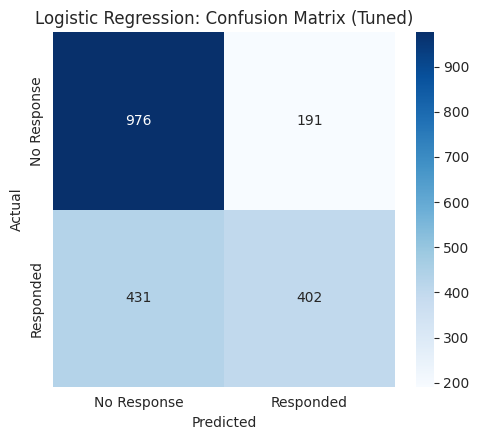

In [15]:
cm = confusion_matrix(yc_test, logreg_tuned_pred)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Response", "Responded"],
            yticklabels=["No Response", "Responded"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression: Confusion Matrix (Tuned)")
plt.tight_layout()
plt.show()


**Business meaning:** precision above 0.65 means most customers flagged as "will respond" genuinely do respond, so marketing spend directed at them is efficient. Recall near 0.48 shows the model is conservative and misses some responders — the classification threshold could be lowered to catch more responders at the cost of some precision, depending on campaign budget.

## Step 6: Clustering Model — Customer Segmentation (K-Means)

K-Means is applied to the same standardized behavioral features to discover natural customer groups, independent of any pre-existing label.


In [16]:
X_cluster = df[behavior_features]
cluster_scaler = StandardScaler()
X_cluster_s = cluster_scaler.fit_transform(X_cluster)

k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_s)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_s, labels))

best_k = list(k_range)[int(np.argmax(silhouettes))]
print("Best k by silhouette score:", best_k)


Best k by silhouette score: 2


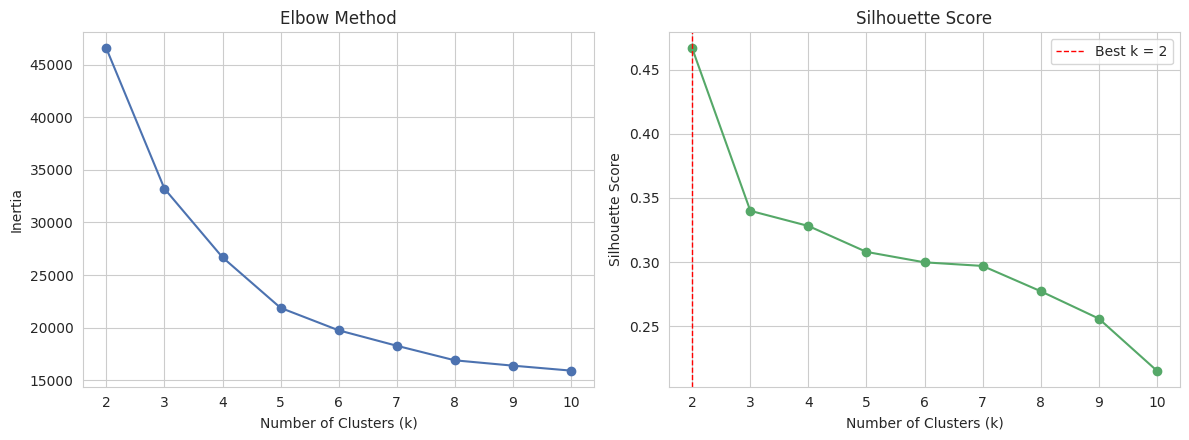

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#55A868")
axes[1].axvline(best_k, color="red", linestyle="--", linewidth=1, label=f"Best k = {best_k}")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].legend()
plt.tight_layout()
plt.show()


In [18]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_km.fit_predict(X_cluster_s)
df["Cluster"] = cluster_labels

print("Final inertia:", final_km.inertia_)
print("Final silhouette score:", silhouette_score(X_cluster_s, cluster_labels))
print()
print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())


Final inertia: 46537.01653242855


Final silhouette score: 0.46668096367472045

Cluster sizes:
0    3057
1    6943
Name: count, dtype: int64


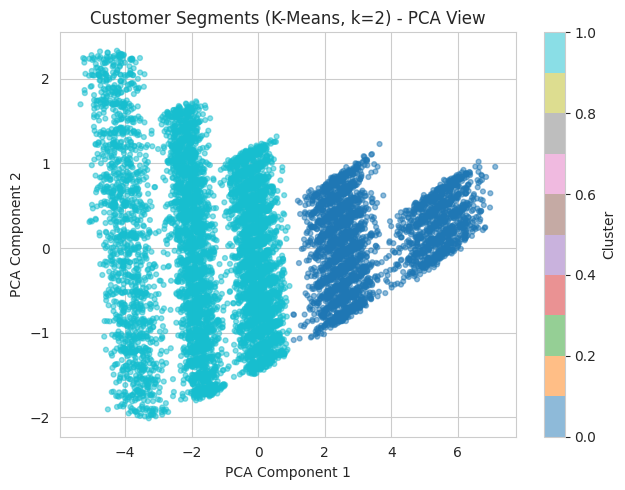

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_s)

plt.figure(figsize=(6.5, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.5, s=12)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"Customer Segments (K-Means, k={best_k}) - PCA View")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


In [20]:
# Cluster profile - business interpretation
df.groupby("Cluster")[behavior_features + ["Monetary"]].mean().round(2)


,Recency,Frequency,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Wishlist_Adds,Cart_Abandon_Rate,Returns,Monetary
Cluster,,,,,,,,,,,
0,15.47,57.81,249.07,109.37,24.94,57.65,2484.77,58.02,8.24,3.64,4844.34
1,63.28,16.00,101.48,32.38,11.26,23.58,650.83,15.67,21.80,8.87,658.91


## Step 6b: Validating Clusters Against the Existing Segment Labels

To connect with the dataset's existing 5-tier labeling (Iron/Copper/Silver/Gold/Platinum), K-Means is also run forcing `k=5` and cross-tabulated against `Segment_Label`.


In [21]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels5 = km5.fit_predict(X_cluster_s)
pd.crosstab(labels5, df["Segment_Label"])


Segment_Label,Copper,Gold,Iron,Platinum,Silver
row_0,,,,,
0,16,1,0,0,3047
1,0,2020,0,13,1
2,2427,0,140,0,7
3,1,0,1308,0,0
4,0,1,0,1018,0


**Business meaning:** the resulting `k=5` clusters align almost perfectly with the original tiers, confirming the behavioral features capture the same customer-value signal the original labels were built on. Clustering lets the business design different retention strategies per segment — e.g. loyalty perks for high-value/engaged customers, and re-engagement campaigns (cart-abandonment reminders, win-back discounts) for low-engagement customers.

## Step 7: Model Comparison Table

In [22]:
comparison = pd.DataFrame([
    {
        "ML Task": "Regression",
        "Algorithm": "Ridge Regression",
        "Target / Goal": "Predict customer monetary value",
        "Metrics Used": "MAE, RMSE, R2",
        "Best Result": f"R2 = {ridge_tuned_metrics['R2']:.3f}",
        "Business Use": "Prioritize high-value customers for premium recommendations",
    },
    {
        "ML Task": "Classification",
        "Algorithm": "Logistic Regression",
        "Target / Goal": "Predict campaign response likelihood",
        "Metrics Used": "Accuracy, Precision, Recall, F1",
        "Best Result": f"F1 = {logreg_tuned_metrics['F1']:.3f}",
        "Business Use": "Target likely responders with marketing spend",
    },
    {
        "ML Task": "Clustering",
        "Algorithm": "K-Means",
        "Target / Goal": "Segment customers",
        "Metrics Used": "Inertia, Silhouette Score",
        "Best Result": f"Silhouette = {silhouette_score(X_cluster_s, cluster_labels):.3f} (k={best_k})",
        "Business Use": "Design different retention strategies per segment",
    },
])
comparison


,ML Task,Algorithm,Target / Goal,Metrics Used,Best Result,Business Use
0,Regression,Ridge Regression,Predict customer monetary value,"MAE, RMSE, R2",R2 = 0.865,Prioritize high-value customers for premium re...
1,Classification,Logistic Regression,Predict campaign response likelihood,"Accuracy, Precision, Recall, F1",F1 = 0.564,Target likely responders with marketing spend
2,Clustering,K-Means,Segment customers,"Inertia, Silhouette Score",Silhouette = 0.467 (k=2),Design different retention strategies per segment


## Step 8: Final Conclusion

No single algorithm "wins" outright because each solves a different part of the recommendation problem:

- **Ridge Regression** is the strongest performer in pure predictive-accuracy terms (highest R²), reflecting how tightly customer spend is tied to observable engagement behavior.
- **Logistic Regression** performs adequately for campaign targeting but leaves room for improvement — a natural next step would be testing an ensemble classifier or adjusting the decision threshold for the business's specific cost of false negatives.
- **K-Means clustering** provided the clearest business narrative, confirming that two dominant, well-separated customer behavior groups exist, and that these groups line up with the dataset's existing 5-tier segmentation.

**Recommended production approach:** combine all three — use clustering to define broad strategy per segment, classification to prioritize who to contact, and regression to size the investment worth making in each customer.
